In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import cmasher as cmr
import matplotlib.patches as ps

from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter
from sm import NeuralNet
from models import CondSM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 10,    # affects horizontal colorbar ticks
    "ytick.labelsize": 10,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

cuda


In [2]:
data_type = 'uni_1e7'

state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device)

print("Model loaded")

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

Model loaded


0.006012024048096192


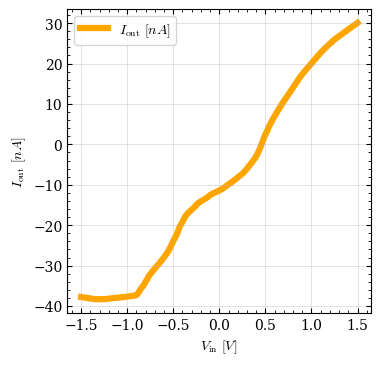

In [3]:
input_idx = 0
min_v = -1.5
max_v = 1.5
N = 500

v_step = float((max_v - min_v) / (N - 1))
print(v_step)
np.random.seed(402)
c_volts = torch.from_numpy(np.random.uniform(min_v, max_v, 6)).expand(N, -1).type(torch.float32)
c_v_left, c_v_right = c_volts[:, :input_idx], c_volts[:, input_idx:]

input_range = torch.linspace(min_v, max_v, N).unsqueeze(1)
input_tensor = torch.cat([c_v_left, input_range, c_v_right], dim=1)
input_tensor = input_tensor.to(device)

model.eval()
with torch.no_grad():
    I_out = model(input_tensor).detach().cpu().numpy().squeeze() * out_scale

wl = 51#51
po = 3#3
I_smooth = savgol_filter(x=I_out, window_length=wl, polyorder=po, delta=v_step, mode='interp')
I_deriv = savgol_filter(x=I_out, window_length=wl, polyorder=po, deriv=1, delta=v_step, mode='interp')

plotting_range = torch.linspace(min_v, max_v, N)

fig, ax = plt.subplots(figsize=(4,4))
ax.set_position([0.22, 0.12, 0.76, 0.83])
ax.minorticks_on()
ax.tick_params(which='both', direction='in')
ax.tick_params(top=True, right=True, which='both')
#ax.plot(plotting_range, I_smooth, lw=1.2, zorder=2, label=r'$\mathrm{SavGol}[I_{\mathrm{out}}] \, \, [nA]$', ls='dashed', color='red')
#ax.plot(plotting_range, I_deriv, c='k', ls='dashdot', label=r'$\mathrm{SavGol}[I_{\mathrm{out}}] / dV_{\mathrm{in}} \, \, [nA / V]$')
ax.plot(plotting_range, I_out, lw=4.5, zorder=1, label=r'$I_{\mathrm{out}} \, \, [nA]$', c='orange')
ax.set_xlabel(r'$V_{\mathrm{in}} \, \, [V]$')
ax.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')
ax.grid(which='major', lw=0.5, alpha=0.5)#ax.grid(which='minor', lw=0.1, alpha=0.5)

#ax.axhline(y=0.0, lw=1.5, ls='--', alpha=1, c='k', zorder=-1)
#ax.hlines(y=0.01, xmin=0.3, xmax=-1.5, color='k')
arrow = ps.FancyArrowPatch(
    (-1.6, 0.01), (0.4, 0.01),
    arrowstyle="<->", mutation_scale=12,
    linewidth=1.5, color="k"
)
#ax.text(x=-0.8, y=0.25, s=r'NDR', fontweight='bold')
#ax.add_patch(arrow)
ax.tick_params(direction='in')
ax.set_box_aspect(1)

plt.legend()
#plt.savefig('iv_and_derivative_from_savgol.pdf', bbox_inches=None, pad_inches=None)
#plt.savefig('iv_for_savgol.pdf', bbox_inches=None, pad_inches=None)
plt.show()

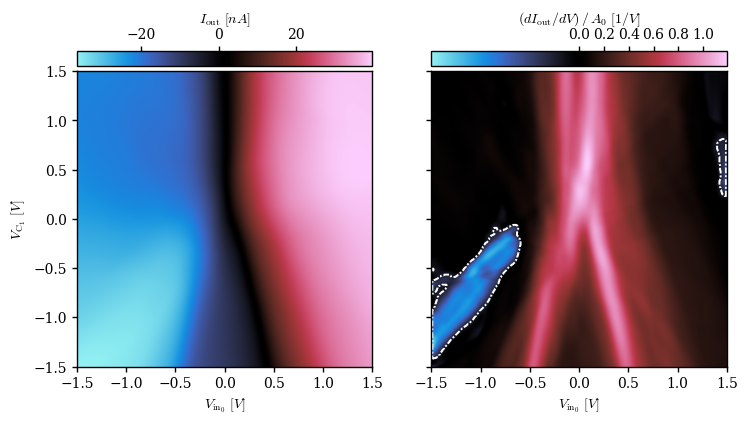

=== NDR comparison metrics ===
thr_norm: 0.016666666666666666
NDR area fraction: 0.0600
min normalized slope: -0.1043
NDR strength (mean excess below -thr): 0.0020


In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors

# optional: morphological cleanup (recommended)
try:
    from scipy.ndimage import binary_opening, binary_closing, label
    HAVE_MORPH = True
except Exception:
    HAVE_MORPH = False

# --- your settings ---
c_sweep_index = 1
input_idx = 0
in_features = 7

N = 500
input_range = torch.linspace(min_v, max_v, N)
c_sweep_range = torch.linspace(min_v, max_v, N)
dx = float((max_v - min_v) / (N - 1))

np.random.seed()
other_controls = torch.zeros(5)  # or random if you want
window_length = 51
poly_order = 3

# --- model eval ---
model.eval()

# columns for other controls
other_control_cols = [k for k in range(in_features) if k not in (c_sweep_index, input_idx)]
assert len(other_control_cols) == len(other_controls), "other_controls length must match remaining input dims"

# --- collect outputs ---
raw_output = []     # list of arrays shape (Npts,)
I_lines = []        # smoothed I for left heatmap
grad_list = []      # dI/dV
for c_v in c_sweep_range:
    input_tensor = torch.empty(N, in_features, dtype=torch.float32)
    input_tensor[:, c_sweep_index] = c_v
    for l, other_c_v in zip(other_control_cols, other_controls):
        input_tensor[:, l] = other_c_v
    input_tensor[:, input_idx] = input_range

    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().squeeze().numpy()

    y_out = y_out * out_scale

    # smooth I for plotting
    I_smooth = savgol_filter(y_out, window_length=window_length, polyorder=poly_order, mode='interp')
    I_lines.append(I_smooth)
    raw_output.append(y_out)

    # derivative (SG polynomial derivative)
    dIdV = savgol_filter(y_out, window_length=window_length, polyorder=poly_order,
                         deriv=1, delta=dx, mode='interp')
    grad_list.append(dIdV)

# stack into matrices: (Nlines, Npts) where Nlines == len(c_sweep_range) == N
c_i_mat = np.stack(I_lines, axis=0)
I_raw   = np.stack(raw_output, axis=0)
grad    = np.stack(grad_list, axis=0)

# --- percentile-based normalization for comparable slopes ---
# robust I-range per line (over Vin)
p_lo, p_hi = 5, 95
I_lo = I_raw.min()#np.percentile(I_raw, p_lo, axis=1, keepdims=True)
I_hi = I_raw.max()#np.percentile(I_raw, p_hi, axis=1, keepdims=True)
dI   = (I_hi - I_lo) + 1e-12  # avoid divide-by-zero

Vspan = 1#float(input_range[-1] - input_range[0]) + 1e-12
g_norm = grad / (dI / Vspan)  # dimensionless slope

# --- NDR threshold in dimensionless units ---
# threshold is now comparable across devices
thr_norm = 0.05 / float(input_range[-1] - input_range[0])   # try 0.2–0.5; larger => stricter NDR definition
neg_mask = g_norm < -thr_norm

# --- optional: clean mask (remove tiny islands / speckle) ---
if HAVE_MORPH:
    neg_mask = binary_opening(neg_mask, structure=np.ones((3, 3)))
    neg_mask = binary_closing(neg_mask, structure=np.ones((5, 5)))

    # optional: keep only largest connected component (if you expect one blob)
    # lab, n = label(neg_mask)
    # if n > 0:
    #     sizes = np.bincount(lab.ravel())
    #     sizes[0] = 0
    #     neg_mask = lab == sizes.argmax()

# --- plot ---
# choose cmap
try:
    import cmasher as cmr
    cmap = plt.get_cmap('cmr.redshift')
except Exception:
    cmap = plt.get_cmap('plasma')

# center colormap at 0 for normalized slope
gmin = np.nanmin(g_norm)
gmax = np.nanmax(g_norm)
if gmin < 0 < gmax:
    norm = mcolors.TwoSlopeNorm(vmin=gmin, vcenter=0.0, vmax=gmax)
else:
    norm = None

latex_lw = 404.02908
in_inch = latex_lw / 72.27
scale = 1.5

fig, ax = plt.subplots(ncols=2, figsize=(scale*in_inch, scale*in_inch))
fig.subplots_adjust(top=0.9, bottom=0.08)

for a in ax:
    a.spines[:].set_linewidth(1.)
    a.tick_params(width=1.)

extent = [float(input_range[0]), float(input_range[-1]),
          float(c_sweep_range[0]), float(c_sweep_range[-1])]

im_0 = ax[0].imshow(c_i_mat, origin='lower', extent=extent, cmap=cmap)
im_1 = ax[1].imshow(g_norm, origin='lower', extent=extent, cmap=cmap, norm=norm)

# colorbar 0 (I)
divider_0 = make_axes_locatable(ax[0])
cax_0 = divider_0.append_axes('top', size='5%', pad=0.05)
cb_0 = fig.colorbar(im_0, cax=cax_0, orientation='horizontal')
cb_0.ax.xaxis.set_ticks_position('top')
cb_0.ax.xaxis.set_label_position('top')
cb_0.outline.set_linewidth(1.)
cb_0.ax.xaxis.set_tick_params(width=1.)
cb_0.set_label(label=r'$I_{\mathrm{out}} \, \, [nA]$')

# colorbar 1 (normalized slope)
divider_1 = make_axes_locatable(ax[1])
cax_1 = divider_1.append_axes('top', size='5%', pad=0.05)
cb_1 = fig.colorbar(im_1, cax=cax_1, orientation='horizontal')
cb_1.ax.xaxis.set_ticks_position('top')
cb_1.ax.xaxis.set_label_position('top')
cb_1.outline.set_linewidth(1.)
cb_1.ax.xaxis.set_tick_params(width=1.)
cb_1.set_label(label=r'$(dI_{\mathrm{out}}/dV) \, / \, A_0 \, \, [1/V]$')

# contour outline for NDR region
cs = ax[1].contour(neg_mask.astype(float), levels=[0.5], colors='w',
                   linewidths=1.4, linestyles=[(0, (3, 1, 1, 1))], extent=extent)

ax[0].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}} \, \, [V]$')
ax[0].set_ylabel(fr'$V_{{\mathrm{{C_{{{c_sweep_index}}}}}}} \, \, [V]$')

ax[1].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}} \, \, [V]$')
ax[1].tick_params(labelleft=False)

plt.savefig(f'data_typ={data_type}_ndr_regions_c={c_sweep_index}_in={input_idx}.pdf', bbox_inches='tight')
plt.show()

# --- comparison metrics you can log per device ---
# 1) NDR area fraction (what % of the (c,V) plane is NDR)
ndr_area_frac = float(np.mean(neg_mask))

# 2) most negative normalized slope (how steep)
min_g_norm = float(np.min(g_norm))

# 3) integrated NDR "strength" (dimensionless)
# sum of (-g_norm) where negative beyond threshold, times normalized area element
# (area element here is just dx*dc; if you want dimensionless, keep it as mean)
ndr_strength = float(np.mean(np.clip(-(g_norm + thr_norm), 0, None)))

print("=== NDR comparison metrics ===")
print(f"thr_norm: {thr_norm}")
print(f"NDR area fraction: {ndr_area_frac:.4f}")
print(f"min normalized slope: {min_g_norm:.4f}")
print(f"NDR strength (mean excess below -thr): {ndr_strength:.4f}")

tensor([0., 0., 0., 0., 0.])


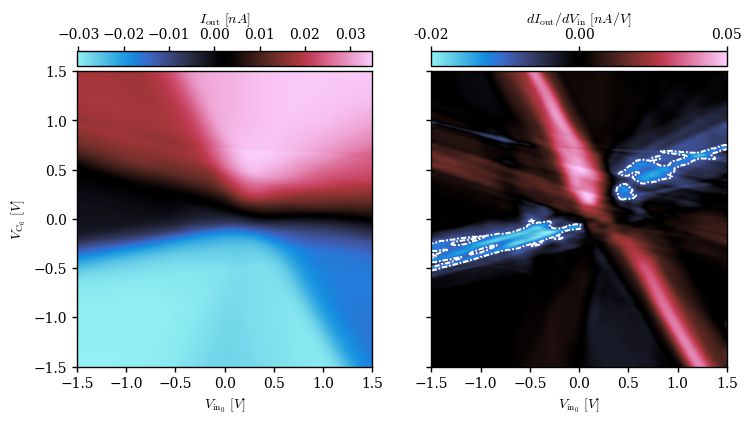

In [50]:
"""c_sweep_index = 6
input_idx = 0

in_features = 7

N = 500
input_range = torch.linspace(min_v, max_v, N)
c_sweep_range = torch.linspace(min_v, max_v, N)
dx = float((max_v - min_v) / (N - 1))

np.random.seed()
other_controls = torch.zeros(5)#torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)
print(other_controls)
window_length = 51
poly_order = 3

I_lines = []
raw_output = []
model.eval()
other_control_cols = []
for k in range(in_features):
    if k not in (c_sweep_index, input_idx):
        other_control_cols.append(k)        

for c_v in c_sweep_range:
    input_tensor = torch.empty(N, 7, dtype=torch.float32)
    input_tensor[:, c_sweep_index] = c_v
    for l, other_c_v in zip(other_control_cols, other_controls):
        input_tensor[:, l] = other_c_v
    input_tensor[:, input_idx] = input_range
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().squeeze().numpy()
    I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
    I_lines.append(I_smooth)
    raw_output.append(y_out)
    
c_i_mat = np.stack(I_lines)

grad_list = []
for line in raw_output:
    #dIdV = np.gradient(line, dx)
    dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
    grad_list.append(dIdV)
grad = np.stack(grad_list)    

cmap = cmr.rainforest
cmap = plt.get_cmap('cmr.redshift')
#cmap = plt.get_cmap('plasma')

g_min = np.nanmin(grad)
g_max = np.nanmax(grad)

if g_min < 0 < g_max:
    norm = mcolors.TwoSlopeNorm(vmin=g_min, vcenter=0.0, vmax=g_max)
else:
    norm = None

latex_lw = 404.02908
in_inch = latex_lw / 72.27

scale=1.5
fig, ax = plt.subplots(ncols=2, figsize=(scale*in_inch, scale*in_inch))
fig.subplots_adjust(top=0.9, bottom=0.08)

ax[0].spines[:].set_linewidth(1.)
ax[1].spines[:].set_linewidth(1.)

ax[0].tick_params(width=1.)
ax[1].tick_params(width=1.)

extent = [input_range[0], input_range[-1], c_sweep_range[0], c_sweep_range[-1]]
im_0 = ax[0].imshow(c_i_mat, origin='lower', extent=extent, cmap=cmap)
im_1 = ax[1].imshow(grad, origin='lower', extent=extent, cmap=cmap, norm=norm)

divider_0 = make_axes_locatable(ax[0])
cax_0 = divider_0.append_axes('top', size='5%', pad=0.05)
cb_0 = fig.colorbar(im_0, cax=cax_0, orientation='horizontal')
cb_0.ax.xaxis.set_ticks_position('top')
cb_0.ax.xaxis.set_label_position('top')
cb_0.outline.set_linewidth(1.)
cb_0.ax.xaxis.set_tick_params(width=1.)
cb_0.set_label(label=r'$I_{\mathrm{out}} \, \, [nA]$')

divider_1 = make_axes_locatable(ax[1])
cax_1 = divider_1.append_axes('top', size='5%', pad=0.05)
#ticks = np.linspace(grad.min(), grad.max(), 3)
ticks = [grad.min(), 0.0, grad.max()]
cb_1 = fig.colorbar(im_1, cax=cax_1, orientation='horizontal')
cb_1.ax.xaxis.set_ticks_position('top')
cb_1.ax.xaxis.set_label_position('top')
cb_1.outline.set_linewidth(1.)
cb_1.ax.xaxis.set_tick_params(width=1.)
cb_1.set_label(label=r'$dI_{\mathrm{out}} / dV_{\mathrm{in}}  \, \, [nA/V]$')
cb_1.set_ticks(ticks)
cb_1.ax.set_xticklabels([f'{t:.2f}' for t in ticks])

eps = 1e-9
neg_mask = grad < -1e-2
#print(neg_mask.mean())
cs = ax[1].contour(neg_mask.astype(float), levels=[0.5], colors='w', linewidths=1.4, linestyles=[(0, (3, 1, 1, 1))], extent=extent)

ax[0].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}} \, \, [V]$')
ax[0].set_ylabel(fr'$V_{{\mathrm{{C_{{{c_sweep_index}}}}}}} \, \, [V]$')

ax[1].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}} \, \, [V]$')
ax[1].tick_params(labelleft=False)

plt.savefig(f'data_typ={data_type}_ndr_regions_c={c_sweep_index}_in={input_idx}.pdf', bbox_inches='tight')
plt.show()"""

In [41]:
def ndr_regions(model, c_sweep_idx, in_sweep_idx, other_controls, min_v=-1.5, max_v=1.5, resolution=500, window_length=51, poly_order=3):

    model.eval()
    
    in_features = model.layer_dims[0]
    dx = float((max_v - min_v) / (resolution - 1))
    
    I_lines = []
    raw_output = []
    other_control_cols = []

    c_sweep_range = torch.linspace(min_v, max_v, resolution)
    in_sweep_range = torch.linspace(min_v, max_v, resolution)
    
    for k in range(in_features):
        if k not in (c_sweep_idx, in_sweep_idx):
            other_control_cols.append(k)

    for c_v in c_sweep_range:
        input_tensor = torch.empty(resolution, in_features, dtype=torch.float32)
        input_tensor[:, c_sweep_idx] = c_v
        for l, other_c_v in zip(other_control_cols, other_controls):
            input_tensor[:, l] = other_c_v
        input_tensor[:, in_sweep_idx] = in_sweep_range
        input_tensor = input_tensor.to(device)
        with torch.no_grad():
            y_out = model(input_tensor).detach().cpu().squeeze().numpy()
        I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
        I_lines.append(I_smooth)
        raw_output.append(y_out)
        
    I_ij = np.stack(I_lines)

    grad_list = []
    
    for line in raw_output:
        dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
        grad_list.append(dIdV)
    grad_ij = np.stack(grad_list)    

    out_dict = {'I_ij': I_ij, 'grad_ij': grad_ij}

    return out_dict

def ndr_statistics(num_samples, neg_threshold, model, c_sweep_idx, in_sweep_idx, min_v=-1.5, max_v=1.5, resolution=500, window_length=51, poly_order=3):

    ndr_area_list = []
    peak_strength_list = []
    avg_negativity_list = []
    
    for _ in range(num_samples):

        other_controls = torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)
        out = ndr_regions(model=model, c_sweep_idx=c_sweep_idx, in_sweep_idx=in_sweep_idx, other_controls=other_controls, min_v=min_v, max_v=max_v, resolution=resolution, window_length=window_length, poly_order=poly_order)
        
        neg_mask = out['grad_ij'] < -neg_threshold
        ndr_area_list.append(neg_mask.mean())

        min_peak = out['grad_ij'].min()
        max_peak = out['grad_ij'].max()

        peak_strength = np.abs(min_peak) / (np.abs(max_peak) + 1e-12)
        
        peak_strength_list.append(peak_strength)

        neg_vals = out['grad_ij'][out['grad_ij'] < 0.0]

        if neg_vals.size > 0:
            avg_negativity_list.append(neg_vals.mean())
        if neg_vals.size == 0:
            avg_negativity_list.append(0.0)

    ndr_area_avg = np.array(ndr_area_list).mean()
    peak_strength_avg = np.array(peak_strength_list).mean()
    avg_negativity_avg = np.array(avg_negativity_list).mean()

    ndr_stats_dict = {
        'ndr_area_samples': ndr_area_list,
        'peak_strength_samples': peak_strength_list,
        'avg_negativity_samples': avg_negativity_list
    }

    return ndr_stats_dict

In [42]:
stats = ndr_statistics(num_samples=100, neg_threshold=0.001, model=model, c_sweep_idx=1, in_sweep_idx=0, min_v=-1.5, max_v=1.5, resolution=100, window_length=51, poly_order=3)

print(np.mean(stats['ndr_area_samples']) * 100)
print(np.mean(stats['peak_strength_samples']))
print(np.mean(stats['avg_negativity_samples']))

26.719099999999997
1.0426841
-0.12792152


In [53]:
state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_radial_n_a=200.pth', weights_only=False, map_location='cpu')
args = state_dict['args']

model = NeuralNet(args['layer_dims'], args['x_mean'], args['x_std'], args['y_mean'], args['y_std'], batch_norm=True)
model.load_state_dict(state_dict['model_state_dict'])

model = model.to(device)

controls = [1, 2, 3, 4, 5, 6]

area_mean = []
peak_mean = []
negativity_mean = []

area_std = []
peak_std = []
negativity_std = []

for c_idx in controls:

    stats = ndr_statistics(num_samples=200, neg_threshold=0.01, model=model, c_sweep_idx=c_idx, in_sweep_idx=0, min_v=-1.5, max_v=1.5, resolution=100, window_length=51, poly_order=3)
    ndr_areas_samples = np.array(stats['ndr_area_samples'])
    peak_strength_samples = np.array(stats['peak_strength_samples'])
    avg_negativity_samples = np.array(stats['avg_negativity_samples'])
    
    area_mean.append(ndr_areas_samples.mean())
    area_std.append(ndr_areas_samples.std())
    
    peak_mean.append(peak_strength_samples.mean())
    peak_std.append(peak_strength_samples.std())
    
    negativity_mean.append(avg_negativity_samples.mean())
    negativity_std.append(avg_negativity_samples.std())
    print(c_idx)

1
2
3
4
5
6


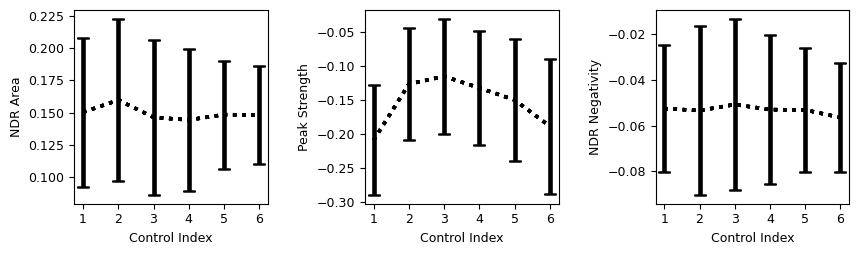

In [54]:
ncols = 3
fig, ax = plt.subplots(ncols=ncols, figsize=(10, 10))
fig.subplots_adjust(wspace=0.5)

for a in ax:
    a.set_box_aspect(1)
    a.set_xticks(np.arange(1, 7, 1))
    a.set_xlabel(r'Control Index')

for c_idx in controls:
    ax[0].errorbar(
        controls,
        area_mean,
        yerr=area_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    )
    ax[0].set_ylabel(f'NDR Area')

    ax[1].errorbar(
        controls,
        peak_mean,
        yerr=peak_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    ) 
    ax[1].set_ylabel(f'Peak Strength')

    ax[2].errorbar(
        controls,
        negativity_mean,
        yerr=negativity_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    )
    ax[2].set_ylabel(f'NDR Negativity')

plt.savefig(f'/home/hd/hd_hd/hd_gy283/kmc_project/plots/ndr_statistics_radial.pdf')